### Simulated Tempering Implementation


Simulated Tempering (ST) belongs to the tempering family together with Parallel Tempering (PT).

**Plan in this notebook**

1. Run an **SMC sampler** to build a tempering ladder $\{\lambda_t\}$ and estimates of intermediate normalizing constants $\{\log Z_t\}$.
2. Define the ST targets
   $$
   \pi_t(x)=\frac{1}{Z_t}\,\tilde\pi_{\lambda_t}(x),\qquad
   \tilde\pi_{\lambda}(x)=\pi_0(x)^{1-\lambda}\pi_1(x)^{\lambda}.
   $$
   With a uniform temperature prior, each ladder level is visited roughly equally often.
3. Transition $(t,x)\to(t',x')$ in two Metropolis–Hastings substeps:
   - **Explore:** $x'=x+\mathcal N(0,\sigma^2 I)$ at fixed $t$.
   - **Jump:** propose $t'\in\{t-1,t+1\}$ (boundary-aware proposal $q$), keep $x$ fixed.
4. Collect samples only when the chain is at the **cold** level $t=T$ ($\lambda_T=1$).

Compare later with SMC and Parallel Tempering on the same targets.


In [18]:
from pathlib import Path
import runpy

for _root in [Path.cwd(), *Path.cwd().parents]:
    _setup = _root / "setup_path.py"
    if _setup.is_file():
        runpy.run_path(str(_setup), run_name="__setup_path__")
        break

from dataclasses import dataclass

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import random
from jax.scipy.stats import norm

from libs import SMC


### State and ST sampler

State is the pair `(t_idx, x)` where `t_idx` indexes the SMC ladder
`lambda_path[t_idx]` with matching `log_z_path[t_idx]`.


In [19]:
@dataclass
class TemperingState:
    """ST Markov state: ladder index + configuration."""
    t_idx: int
    x: jnp.ndarray


class SimulatedTempering:
    """Simulated Tempering on an SMC tempering ladder.

    Joint target (uniform temperature prior):
        pi(t, x) ~ pi_t(x) = tilde_pi_{lambda_t}(x) / Z_t

    Moves
    -----
    explore : x' = x + N(0, step_size^2 I), MH at fixed t
    jump    : t' in {t-1, t+1} (or only the existing neighbor at a bound),
              MH with density ratio * q(t|t') / q(t'|t)
    """

    def __init__(
        self,
        smc: SMC,
        lambda_path,
        log_z_path,
        step_size: float = 0.1,  # explore proposal x' = x + N(0, step_size^2 I)
        seed: int = 0,
    ):
        self.smc = smc
        self.lambda_path = jnp.asarray(lambda_path, dtype=float)
        self.log_z_path = jnp.asarray(log_z_path, dtype=float)
        if self.lambda_path.shape != self.log_z_path.shape:
            raise ValueError("lambda_path and log_z_path must have the same length")
        if int(self.lambda_path.shape[0]) < 2:
            raise ValueError("need at least 2 ladder levels")
        self.n_levels = int(self.lambda_path.shape[0])
        self.t_cold = self.n_levels - 1  # lambda = 1
        self.t_hot = 0                   # lambda = 0
        self.step_size = float(step_size)
        self._key = random.key(seed)

        # Precompute unnormalized log-densities for each ladder level.
        self._unnorm_logpdfs = [
            (lambda lam: (lambda x: smc.get_intermediate_logpdf(x, float(lam))))(lam)
            for lam in np.asarray(self.lambda_path)
        ]

    def _split_key(self):
        self._key, sub = random.split(self._key)
        return sub

    def unnorm_logpdf(self, t_idx: int, x):
        return self._unnorm_logpdfs[int(t_idx)](x)

    def log_pi_t(self, t_idx: int, x):
        """log pi_t(x) = log tilde_pi(x) - log Z_t."""
        return self.unnorm_logpdf(t_idx, x) - self.log_z_path[int(t_idx)]

    def _neighbor_choices(self, t_idx: int):
        """Legal temperature neighbors and their proposal probs q(t'|t)."""
        t = int(t_idx)
        if t <= 0:
            return [1], [1.0]
        if t >= self.n_levels - 1:
            return [self.n_levels - 2], [1.0]
        return [t - 1, t + 1], [0.5, 0.5]

    def _q_forward(self, t_from: int, t_to: int) -> float:
        neighbors, probs = self._neighbor_choices(t_from)
        for n, p in zip(neighbors, probs):
            if n == int(t_to):
                return float(p)
        return 0.0

    def explore(self, state: TemperingState) -> TemperingState:
        """RW-MH on x at fixed temperature index."""
        key = self._split_key()
        k_prop, k_u = random.split(key)
        x = jnp.asarray(state.x)
        noise = self.step_size * random.normal(k_prop, shape=x.shape)
        x_prop = x + noise

        log_alpha = self.log_pi_t(state.t_idx, x_prop) - self.log_pi_t(state.t_idx, x)
        accept = jnp.log(random.uniform(k_u)) < jnp.minimum(log_alpha, 0.0)
        x_next = jnp.where(accept, x_prop, x)
        return TemperingState(t_idx=state.t_idx, x=x_next)

    def jump(self, state: TemperingState) -> TemperingState:
        """Nearest-neighbor temperature jump at fixed x (boundary-aware q)."""
        key = self._split_key()
        neighbors, probs = self._neighbor_choices(state.t_idx)
        probs = jnp.asarray(probs, dtype=float)
        pick = int(random.choice(key, a=len(neighbors), p=probs))
        t_prop = neighbors[pick]

        q_fwd = self._q_forward(state.t_idx, t_prop)
        q_rev = self._q_forward(t_prop, state.t_idx)
        log_dens = self.log_pi_t(t_prop, state.x) - self.log_pi_t(state.t_idx, state.x)
        log_q = jnp.log(q_rev) - jnp.log(q_fwd)
        log_alpha = log_dens + log_q

        key_u = self._split_key()
        accept = bool(jnp.log(random.uniform(key_u)) < jnp.minimum(log_alpha, 0.0))
        t_next = t_prop if accept else state.t_idx
        return TemperingState(t_idx=t_next, x=state.x)

    def move(self, state: TemperingState) -> TemperingState:
        """One ST transition: explore then jump."""
        return self.jump(self.explore(state))

    def run_excursion(self, x0, max_steps: int = 100_000):
        """Start at hot level t=0; collect cold visits; stop on return to hot.

        Returns
        -------
        cold_samples : list of x visited at t_cold during the excursion
        path_t : list of temperature indices along the path
        n_steps : number of moves performed
        """
        state = TemperingState(t_idx=self.t_hot, x=jnp.asarray(x0, dtype=float))
        cold_samples = []
        path_t = [state.t_idx]

        for step in range(max_steps):
            state = self.move(state)
            path_t.append(state.t_idx)
            if state.t_idx == self.t_cold:
                cold_samples.append(np.asarray(state.x))
            # stop once we return to hot after leaving it
            if step > 0 and state.t_idx == self.t_hot:
                break
        else:
            print(f"[ST] excursion hit max_steps={max_steps} without returning to hot")

        return cold_samples, path_t, step + 1

    def run(
        self,
        x0,
        n_iters: int = 100_000,
        burn_in: int = 1_000,
        thin: int = 1,
        start_at_hot: bool = True,
    ):
        """Fixed-length ST chain; keep thinned cold-level samples after burn-in.

        Returns
        -------
        cold_samples : (n_keep, d) array
        t_trace : (n_iters+1,) temperature index trace
        visit_counts : (n_levels,) visit histogram
        """
        t0 = self.t_hot if start_at_hot else self.t_cold
        state = TemperingState(t_idx=t0, x=jnp.asarray(x0, dtype=float))
        t_trace = [state.t_idx]
        cold = []

        for i in range(n_iters):
            state = self.move(state)
            t_trace.append(state.t_idx)
            if i >= burn_in and (i - burn_in) % thin == 0 and state.t_idx == self.t_cold:
                cold.append(np.asarray(state.x))

        t_trace_arr = np.asarray(t_trace)
        visit_counts = np.bincount(t_trace_arr, minlength=self.n_levels)
        cold_arr = np.stack(cold, axis=0) if cold else np.zeros((0, np.asarray(x0).size))
        return cold_arr, t_trace_arr, visit_counts


### Demo: 1-D Gaussian mixture

Target $\pi_1$ is a bimodal mixture; base $\pi_0$ is standard normal (SMC default prior).
We first build $\{\lambda_t,\log Z_t\}$ with SMC, then run ST on that ladder.


In [20]:
def mixture_logpdf(x):
    """log (0.5 N(-2,1) + 0.5 N(2,1)); supports scalar or SMC batch (n,) / (n,1)."""
    x = jnp.asarray(x)
    if x.ndim >= 1 and x.shape[-1] == 1:
        x = x[..., 0]
    return jnp.logaddexp(
        norm.logpdf(x, loc=-5.0, scale=1.0),
        norm.logpdf(x, loc=5.0, scale=1.0),
    ) - jnp.log(2.0)

Plot the pdf to show how it looks 

/var/folders/1q/w_tnkl8s4bx71tjk7lf2f0z00000gn/T/ipykernel_11237/4159264753.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


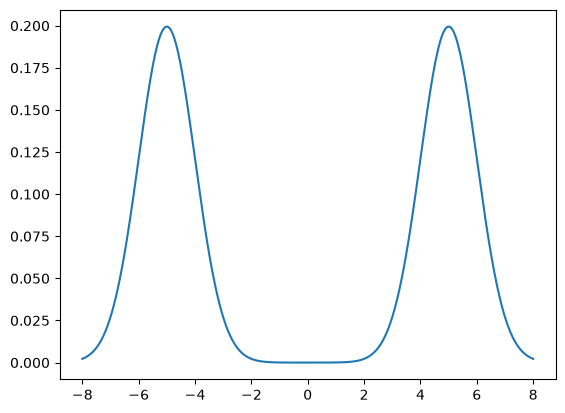

In [21]:
from matplotlib import pyplot as plt 
import numpy as np 

fig, ax = plt.subplots()
xx = np.linspace(-8, 8, 1000) 
yy = np.exp(mixture_logpdf(xx))

ax.plot(xx, yy)
fig.show()

In [22]:
# --- Stage 1: SMC ladder + Z_t ---
N_SMC = 2_000
smc = SMC(dims=1, target_dist_logpdf=mixture_logpdf, key=random.key(0))
smc.reset(no_samples=N_SMC)
lambda_path, log_z_path, tot_log_z = smc.build_intermediate_dists(
    mcmc_iters=10, verbose=True
)

print(f"ladder size = {len(lambda_path)}")
print(f"lambda_path = {[round(float(l), 4) for l in lambda_path]}")
print(f"log_z_path  = {[round(float(z), 4) for z in log_z_path]}")
print(f"tot log Z   = {float(tot_log_z):.4f}")


[SMC] step 0: lambda=0.0 -> 0.1422218233346939, diff_log_z=-1.1683144569396973
[SMC] step 1: lambda=0.1422218233346939 -> 0.2659308910369873, diff_log_z=-0.8003077507019043
[SMC] step 2: lambda=0.2659308910369873 -> 0.3827378451824188, diff_log_z=-0.5150399208068848
[SMC] step 3: lambda=0.3827378451824188 -> 0.4931175708770752, diff_log_z=-0.21534490585327148
[SMC] step 4: lambda=0.4931175708770752 -> 0.6002053618431091, diff_log_z=0.04938840866088867
[SMC] step 5: lambda=0.6002053618431091 -> 0.7057244777679443, diff_log_z=0.32723045349121094
[SMC] step 6: lambda=0.7057244777679443 -> 0.8129988312721252, diff_log_z=0.6368865966796875
[SMC] step 7: lambda=0.8129988312721252 -> 0.9245262742042542, diff_log_z=0.9332122802734375
[SMC] final step: lambda=0.9245262742042542 -> 1.0
ladder size = 10
lambda_path = [0.0, 0.1422, 0.2659, 0.3827, 0.4931, 0.6002, 0.7057, 0.813, 0.9245, 1.0]
log_z_path  = [0.0, -1.1683, -1.9686, -2.4837, -2.699, -2.6496, -2.3224, -1.6855, -0.7523, 0.0512]
tot log Z

In [23]:
# --- Stage 2: Simulated Tempering on the SMC ladder ---
st = SimulatedTempering(
    smc=smc,
    lambda_path=lambda_path,
    log_z_path=log_z_path,
    step_size=0.05,  # lower explore variance to raise RW-MH acceptance
    seed=1,
)

# start near the prior / hot level
x0 = jnp.array(0.0)
cold_samples, t_trace, visit_counts = st.run(
    x0,
    n_iters=20_000,
    burn_in=2_000,
    thin=5,
    start_at_hot=True,
)

print(f"cold samples kept: {cold_samples.shape[0]}")
print(f"visit counts by level: {visit_counts.tolist()}")
print(f"visit fractions: {(visit_counts / visit_counts.sum()).round(3).tolist()}")
print(f"lambda at levels: {[round(float(l), 3) for l in lambda_path]}")


cold samples kept: 94
visit counts by level: [3619, 3114, 2774, 2552, 2198, 1932, 1524, 1097, 676, 515]
visit fractions: [0.181, 0.156, 0.139, 0.128, 0.11, 0.097, 0.076, 0.055, 0.034, 0.026]
lambda at levels: [0.0, 0.142, 0.266, 0.383, 0.493, 0.6, 0.706, 0.813, 0.925, 1.0]


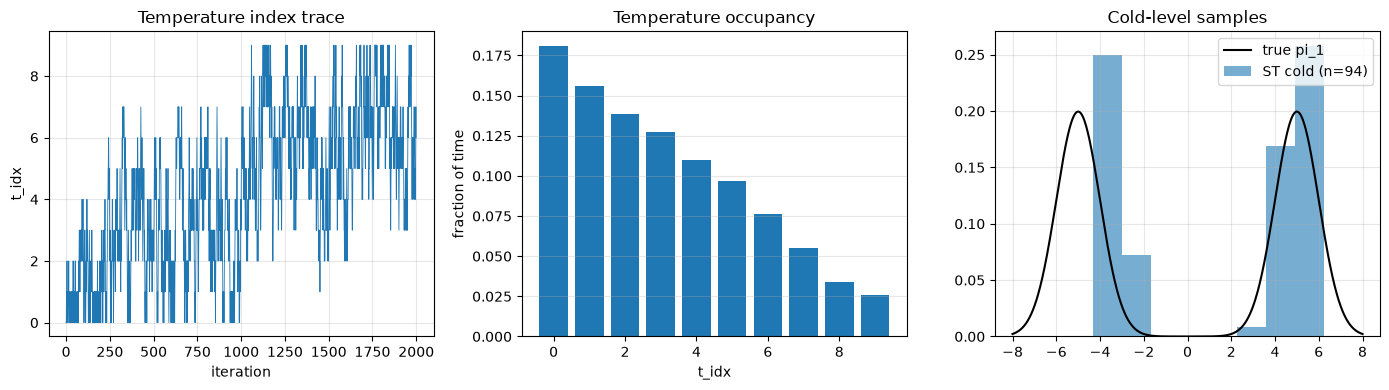

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# temperature trace (first 2k steps)
axes[0].plot(t_trace[:2000], lw=0.6)
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("t_idx")
axes[0].set_title("Temperature index trace")
axes[0].grid(alpha=0.3)

# visit histogram
axes[1].bar(np.arange(st.n_levels), visit_counts / visit_counts.sum())
axes[1].set_xlabel("t_idx")
axes[1].set_ylabel("fraction of time")
axes[1].set_title("Temperature occupancy")
axes[1].grid(axis="y", alpha=0.3)

# cold-level histogram vs true mixture density
xs = np.linspace(-8, 8, 1000)
true_dens = 0.5 * (
    np.exp(np.asarray(norm.logpdf(xs, -5, 1)))
    + np.exp(np.asarray(norm.logpdf(xs, 5, 1)))
)
axes[2].plot(xs, true_dens, label="true pi_1", color="black")
if cold_samples.size:
    axes[2].hist(
        cold_samples.ravel(),
        bins='auto',
        density=True,
        alpha=0.6,
        label=f"ST cold (n={cold_samples.shape[0]})",
    )
axes[2].set_title("Cold-level samples")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Optional: excursion sampler

Start at the hot level $t=0$, collect every visit to the cold level, and stop when the chain first returns to $t=0$. Repeat over several independent excursions and pool cold samples.


excursion 00: steps=   14, cold visits=   0
excursion 01: steps=    2, cold visits=   0
excursion 02: steps=   27, cold visits=   0
excursion 03: steps=    2, cold visits=   0
excursion 04: steps=    2, cold visits=   0
excursion 05: steps=    3, cold visits=   0
excursion 06: steps=    2, cold visits=   0
excursion 07: steps=    3, cold visits=   0
excursion 08: steps=    4, cold visits=   0
excursion 09: steps=    5, cold visits=   0
excursion 10: steps=    2, cold visits=   0
excursion 11: steps=    5, cold visits=   0
excursion 12: steps=   53, cold visits=   3
excursion 13: steps=    2, cold visits=   0
excursion 14: steps=    3, cold visits=   0
excursion 15: steps=    2, cold visits=   0
excursion 16: steps=   43, cold visits=   0
excursion 17: steps=    2, cold visits=   0
excursion 18: steps=    2, cold visits=   0
excursion 19: steps=    2, cold visits=   0
excursion 20: steps=    2, cold visits=   0
excursion 21: steps=   24, cold visits=   0
excursion 22: steps=    4, cold 

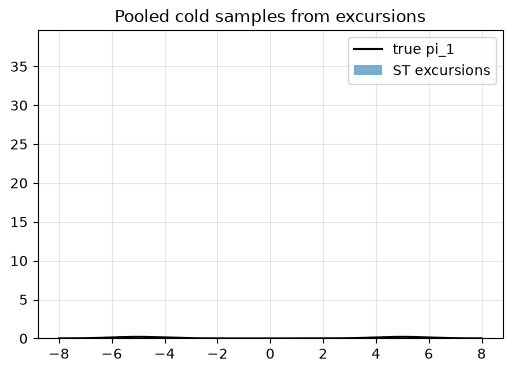

In [25]:
rng = np.random.default_rng(0)
n_excursions = 30
all_cold = []
excursion_lengths = []

for i in range(n_excursions):
    x_start = jnp.asarray(float(rng.normal()))
    cold_i, path_t, n_steps = st.run_excursion(x_start, max_steps=50_000)
    all_cold.extend(cold_i)
    excursion_lengths.append(n_steps)
    print(f"excursion {i:02d}: steps={n_steps:5d}, cold visits={len(cold_i):4d}")

all_cold = np.stack(all_cold, axis=0) if all_cold else np.zeros((0, 1))
print(f"\npooled cold samples: {all_cold.shape[0]}")
print(
    f"excursion length mean/median: "
    f"{np.mean(excursion_lengths):.1f} / {np.median(excursion_lengths):.1f}"
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(xs, true_dens, label="true pi_1", color="black")
if all_cold.size:
    ax.hist(all_cold.ravel(), bins='auto', density=True, alpha=0.6, label="ST excursions")
ax.set_title("Pooled cold samples from excursions")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


### Notes

- Explore MH uses $\pi_t$ (equivalently $\tilde\pi_{\lambda_t}$; $Z_t$ cancels at fixed $t$).
- Jump MH uses $\pi_{t'}(x)/\pi_t(x)=[\tilde\pi_{\lambda_{t'}}/\tilde\pi_{\lambda_t}]\cdot[Z_t/Z_{t'}]$ times the boundary-aware $q$-ratio.
- Occupancy should be roughly flat across $t$ if SMC $\log Z_t$ estimates are accurate; large imbalance suggests refining the SMC ladder / particle count.
- Next: apply the same ST wrapper to Sudoku / Latin-square targets and compare against SMC and PT.
